# EDA 01 — Data Structure & Quality

**Goal:** Before any analysis, we need to understand what we have — row counts, data types,
missing values, and internal consistency. This is the foundation — errors caught here save
hours of model debugging.

**Tables:** Bronze (all), Silver (silver_cards, silver_prices_history), Gold (gold_card_features, gold_price_features)

**Method:** Descriptive inspection — COUNT, NULL rates, duplicates, primary key verification

**Absorbs:** eda_01_bronze_inventory, eda_02_card_attributes (sources), eda_06_silver_join_quality, pipeline_validation/eda_01_data_quality

---
## Questions to answer
1. Are all tables present and do they have the expected row counts?
2. Which columns have missing values, and is the missingness pattern random or systematic?
3. Are primary keys unique? Does the Scryfall ↔ MTGJson join work correctly?
4. Is the date spine in Silver complete? How long are forward-fill runs?
5. Does oracle_id uniquely map to a card name (split card problem)?

## Setup
Imports and database connections.

In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

In [2]:
# Connect to each DuckDB database layer (read-only to prevent accidental writes)
bronze_connection = duckdb.connect("../../data/bronze/cards.duckdb", read_only=True)
silver_connection = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)
gold_connection = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
# Verify all expected tables are present in each layer and get a quick row count
connections_list = [bronze_connection, silver_connection, gold_connection]

for connection in connections_list:
    rows = {row[0] for row in connection.execute("SHOW TABLES").fetchall()}
    tables_count = len(rows)
    print("Count: ", tables_count, " | Rows: ", rows)

Count:  7  | Rows:  {'bronze_scryfall_meta_history', 'bronze_scryfall_cards', 'bronze_mtgjson_prices_history', 'bronze_tournament_results', 'bronze_format_staples_history', 'bronze_scryfall_prices_history', 'bronze_mtgjson_cards'}
Count:  6  | Rows:  {'silver_cards', 'silver_format_staples_history', 'silver_meta_history', 'silver_tournament_results_history', 'silver_language_prices_history', 'silver_prices_history'}
Count:  9  | Rows:  {'gold_events', 'gold_demand_signals', 'gold_tournament_signals', 'gold_card_features', 'gold_ml_dataset', 'gold_language_premiums', 'gold_format_staples', 'gold_price_features', 'gold_ban_price_impact'}


## 1. Table Sizes — Bronze → Silver → Gold

**Method:** `SELECT COUNT(*)` for each table across all three databases.

**Why:** A missing table means a broken scraper or a failed migration. An unexpected row count
(e.g. 0 rows or 10× too many) signals a pipeline issue before we even start quality analysis.

**Expected values (to verify):**
- Bronze: ~530k Scryfall cards, ~110k MTGJson cards, ~9.7M MTGJson prices
- Silver (7 tables): ~521k silver_cards, ~2.8M silver_prices_history, ~430k silver_language_prices_history
- Gold (7 tables): ~98k gold_card_features, ~3.3M gold_price_features, ~430k gold_language_premiums

**Language-variant tables (added for non-English pricing):**
- `silver_language_prices_history` — daily price snapshots for non-English Scryfall cards,
  keyed on `(scryfall_id, snapshot_date)`. Each row carries a `canonical_uuid` linking it
  to the English printing's UUID, enabling premium computation.
- `gold_language_premiums` — per `(scryfall_id, snapshot_date)` ratio of the language
  variant price to the English canonical price (`eur_lang_premium = lang_eur / canonical_eur`).
  A value of 4.0 means the Japanese version trades at 4× the English price on that date.

In [4]:
# Helper: query COUNT(*) for every table in a given connection
# Returns a list of dicts so we can build a DataFrame for display
def get_table_counts(conn, db_name):
    tables = {r[0] for r in conn.execute("SHOW TABLES").fetchall()}
    rows = []
    for t in tables:
        count = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
        rows.append({"baza": db_name, "tabela": t, "wiersze": count})
    return rows

In [5]:
# Collect row counts for all layers into a single list
data = []
for conn, name in zip(connections_list, ["bronze", "silver", "gold"]):
    data.extend(get_table_counts(conn, name))

In [6]:
# Highlight rows so problem tables (0 or None) stand out visually:
# red = 0 rows (empty table = broken pipeline step)
# orange = None (table missing entirely)
def highlight(row):
    if row["wiersze"] is None:
        return ["background-color: orange"] * len(row)
    if row["wiersze"] == 0:
        return ["background-color: red"] * len(row)
    return [""] * len(row)

In [7]:
# Build sorted DataFrame for a clean tabular view
df = pd.DataFrame(data).sort_values(["baza", "tabela"])

In [8]:
# Display styled table — red/orange rows signal pipeline problems
df.style.apply(highlight, axis=1)

,baza,tabela,wiersze
4,bronze,bronze_format_staples_history,10586
6,bronze,bronze_mtgjson_cards,110544
2,bronze,bronze_mtgjson_prices_history,84420980
1,bronze,bronze_scryfall_cards,531765
0,bronze,bronze_scryfall_meta_history,19089994
5,bronze,bronze_scryfall_prices_history,19089994
3,bronze,bronze_tournament_results,140470
21,gold,gold_ban_price_impact,1
16,gold,gold_card_features,93400
14,gold,gold_demand_signals,18610916


### Observations
```
All expected tables present?              YES
Tables with problems (0 rows or missing): NONE
Bronze table count:                       7
Silver table count:                       6 (includes silver_language_prices_history)
Gold table count:                         9 (includes gold_language_premiums)
Decision: Data complete in all layers. Proceed to quality checks.

Note: silver_cards carries a canonical_uuid column — links each non-English
Scryfall-only card to its English MTGJson UUID via (set_code, collector_number).
Scryfall-only cards without an English counterpart (digital exclusives) keep canonical_uuid = NULL.
```

## 2. Missing Data Rates (NULL rates) — Bronze

**Method:** For bronze_scryfall_cards, bronze_mtgjson_cards, bronze_scryfall_prices_history,
and bronze_mtgjson_prices_history compute NULL% per column. Compare both tables for shared attributes.

**Why:** A column with 100% NULL in both sources will not reach Silver/Gold — but we must
confirm from data, not assume. A NULL rate difference between sources indicates which source
is primary for a given attribute.

**Key attributes to compare:** name, rarity, mana_value/cmc, colors, edhrec_rank, set_code, legalities

**Interpretation:** If Scryfall has 0% NULL and MTGJson has 8% NULL for the same attribute →
Scryfall is primary. Vice versa → MTGJson primary.

In [9]:
# Sample 50k rows from each bronze card table.
# Full tables are 530k / 110k rows — sampling keeps this cell fast
# while still giving a reliable NULL rate estimate.
null_research_dfs: dict = {}

for table in ["bronze_scryfall_cards", "bronze_mtgjson_cards"]:
    null_research_dfs[table] = bronze_connection.execute(
        f"SELECT * FROM {table} LIMIT 50000"
    ).df()

In [10]:
# Compute NULL% per column for each bronze card source.
# Only show columns with at least one NULL to reduce noise.
# Red gradient = high NULL% = unreliable for modeling.
for key, value in null_research_dfs.items():
    null_percentage = value.isna().mean() * 100
    null_percentage = (
        null_percentage[null_percentage > 0]
        .sort_values(ascending=False)
        .to_frame(name="null%")
    )

    display(
        null_percentage.style.background_gradient(cmap="Reds", vmin=0, vmax=100)
        .set_caption(key)
        .format("{:.1f}%")
    )

,null%
defense,100.0%
hand_modifier,100.0%
life_modifier,100.0%
content_warning,100.0%
variation_of,100.0%
attraction_lights,100.0%
flavor_name,99.9%
color_indicator,99.9%
tcgplayer_etched_id,99.8%
loyalty,98.9%


,null%
attraction_lights,100.0%
subsets,100.0%
signature,100.0%
face_printed_name,100.0%
defense,100.0%
life,100.0%
hand,100.0%
face_flavor_name,100.0%
is_textless,100.0%
printed_type,100.0%


In [11]:
# Compute NULL% for Scryfall card attributes
scryfall_nulls = null_research_dfs["bronze_scryfall_cards"].isna().mean() * 100

In [12]:
# Compute NULL% for MTGJson card attributes
mtgjson_nulls = null_research_dfs["bronze_mtgjson_cards"].isna().mean() * 100

In [13]:
# Side-by-side comparison of NULL rates between sources.
# dropna(how='all') keeps only columns that exist in at least one source.
# Columns present in only one source show NaN for the other — expected for source-specific fields.
comparison = (
    pd.DataFrame(
        {
            "scryfall_null%": scryfall_nulls,
            "mtgjson_null%": mtgjson_nulls,
        }
    )
    .dropna(how="all")
    .sort_values("scryfall_null%", ascending=False)
)  # Note: we use dropna here to leave only rows that exists in both tables

In [14]:
# Heatmap view: dark red = high NULL, dark green = complete
comparison.style.background_gradient(cmap="Reds", vmin=0, vmax=100).format("{:.1f}%")

,scryfall_null%,mtgjson_null%
defense,100.0%,100.0%
content_warning,100.0%,nan%
life_modifier,100.0%,nan%
hand_modifier,100.0%,nan%
variation_of,100.0%,nan%
attraction_lights,100.0%,100.0%
flavor_name,99.9%,98.0%
color_indicator,99.9%,99.3%
tcgplayer_etched_id,99.8%,nan%
loyalty,98.9%,99.2%


In [15]:
# Filter to the subset of attributes we plan to use as model features.
# NaN in one source = column doesn't exist there (not a data error).
# Key insight: mana_value is MTGJson-only, set_code is MTGJson-only —
# both will be NULL for 80% of Silver rows (Scryfall-only cards).
# Let's narrow data to only our potetial features.
attrs = [
    "name",
    "rarity",
    "mana_value",
    "colors",
    "edhrec_rank",
    "set_code",
    "lang",
    "artist",
    "promo",
    "full_art",
    "border_color",
    "frame",
    "finishes",
    "set_type",
    "reserved",
    "reprint",
    "oversized",
    "promo_type",
]
comparison.loc[comparison.index.isin(attrs)]

,scryfall_null%,mtgjson_null%
edhrec_rank,6.060,6.058
colors,1.558,0.000
border_color,0.000,0.000
artist,0.000,0.000
finishes,0.000,0.000
lang,0.000,NaN
oversized,0.000,NaN
name,0.000,0.000
full_art,0.000,NaN
frame,0.000,NaN


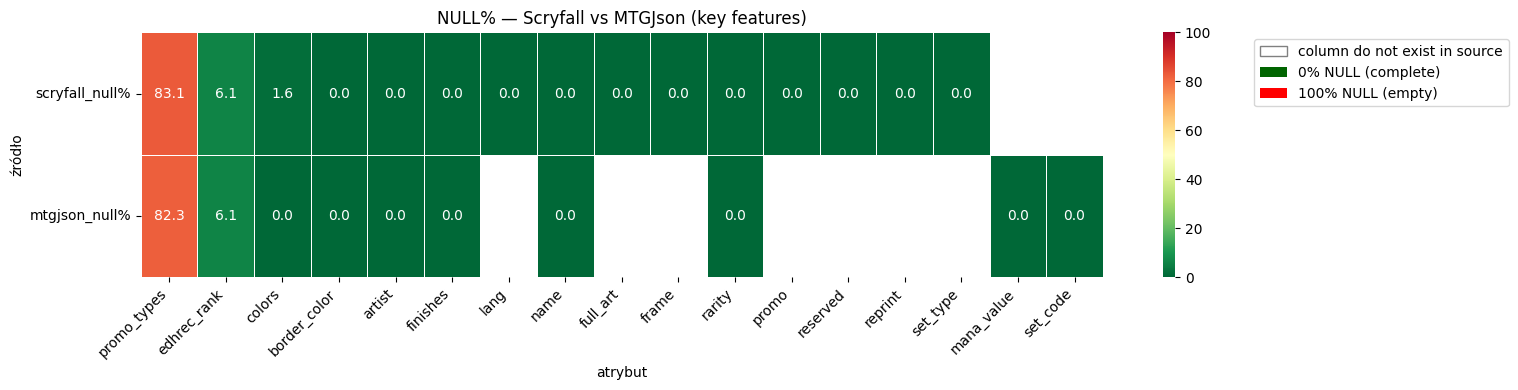

In [16]:
# Visual heatmap comparing NULL% for key features across both sources.
# NaN cells (column absent from source) appear as white with a legend note.
attrs = [
    "name",
    "rarity",
    "mana_value",
    "colors",
    "edhrec_rank",
    "set_code",
    "lang",
    "artist",
    "promo",
    "full_art",
    "border_color",
    "frame",
    "finishes",
    "set_type",
    "reserved",
    "reprint",
    "promo_types",
]

heat_data = comparison.loc[comparison.index.isin(attrs)].T

fig, ax = plt.subplots(figsize=(len(attrs) * 0.9, 4))
sns.heatmap(
    heat_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("NULL% — Scryfall vs MTGJson (key features)")
ax.set_xlabel("atrybut")
ax.set_ylabel("źródło")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0, fontsize=10)

legend = [
    mpatches.Patch(
        facecolor="white", edgecolor="gray", label="column do not exist in source"
    ),
    mpatches.Patch(facecolor="#006400", label="0% NULL (complete)"),
    mpatches.Patch(facecolor="#FF0000", label="100% NULL (empty)"),
]
ax.legend(handles=legend, loc="upper left", bbox_to_anchor=(1.15, 1), frameon=True)

plt.tight_layout()
plt.show()

In [17]:
# Inspect the price JSON structure from Scryfall.
# Prices are stored as a nested JSON blob per row, not as separate columns.
# We need to know the field names before extracting EUR/USD values.
scryfall_price_row = bronze_connection.execute(
    "SELECT eur, eur_foil, usd, usd_foil, tix FROM bronze_scryfall_prices_history WHERE eur IS NOT NULL LIMIT 1"
).df()
print(scryfall_price_row.iloc[0].to_dict())

{'eur': 0.25, 'eur_foil': nan, 'usd': nan, 'usd_foil': nan, 'tix': nan}


In [18]:
# Sample one card's full price history to verify:
# 1. Daily snapshot cadence (no gaps)
# 2. Correct EUR extraction from JSON using ->>'eur'
bronze_connection.execute("""
    SELECT id, snapshot_date, eur
    FROM bronze_scryfall_prices_history
    WHERE id = (
        SELECT id FROM bronze_scryfall_prices_history
        WHERE eur IS NOT NULL
        LIMIT 1
    )
    ORDER BY snapshot_date
""").df()

,id,snapshot_date,eur
0,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-26,0.25
1,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-27,0.25
2,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-28,0.25
3,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-29,0.25
4,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-30,0.25
5,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-05-31,0.25
6,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-06-01,0.25
7,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-06-02,0.25
8,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-06-03,0.25
9,f74900ca-7f0d-460c-86b0-b515c8b44e67,2026-06-04,0.25


In [19]:
# Inspect the MTGJson price JSON structure.
# MTGJson uses a deeply nested format: paper.cardmarket.retail.normal for EUR,
# paper.tcgplayer.retail.normal for USD — different paths than Scryfall.
mtgjson_price_row = bronze_connection.execute(
    "SELECT * FROM bronze_mtgjson_prices_history LIMIT 5"
).df()

print(mtgjson_price_row.to_string())

                                   uuid snapshot_date    retailer tx_type  finish  price
0  3c129e3d-4c46-576b-a19b-e3628d40faf2    2026-02-24   tcgplayer  retail    foil   2.18
1  3c129e3d-4c46-576b-a19b-e3628d40faf2    2026-02-24   tcgplayer  retail  normal   0.24
2  3c129e3d-4c46-576b-a19b-e3628d40faf2    2026-02-24    manapool  retail    foil   3.05
3  3c12ab0d-cf96-5f32-8836-75c43c9a1917    2026-02-24    manapool  retail  normal   0.52
4  3c12ab0d-cf96-5f32-8836-75c43c9a1917    2026-02-24  cardmarket  retail  normal   1.23


In [20]:
# Define per-source price queries that extract EUR/USD from JSON.
# QUALIFY ROW_NUMBER() limits to 25k rows per snapshot date to keep query fast
# while preserving the per-date NULL rate pattern.
price_tables = {
    "scryfall_prices": """
        SELECT snapshot_date,
            usd,
            usd_foil,
            eur,
            eur_foil
        FROM bronze_scryfall_prices_history
        QUALIFY ROW_NUMBER() OVER (PARTITION BY snapshot_date ORDER BY id) <= 25000
    """,
}

In [21]:
# Price columns to check across all sources
price_cols = ["eur", "usd", "eur_foil", "usd_foil"]


scryfall_prices — NULL% per column:
eur         83.051000
usd         84.122444
eur_foil    88.431778
usd_foil    88.829000
Rows with no price at all: 80.1%


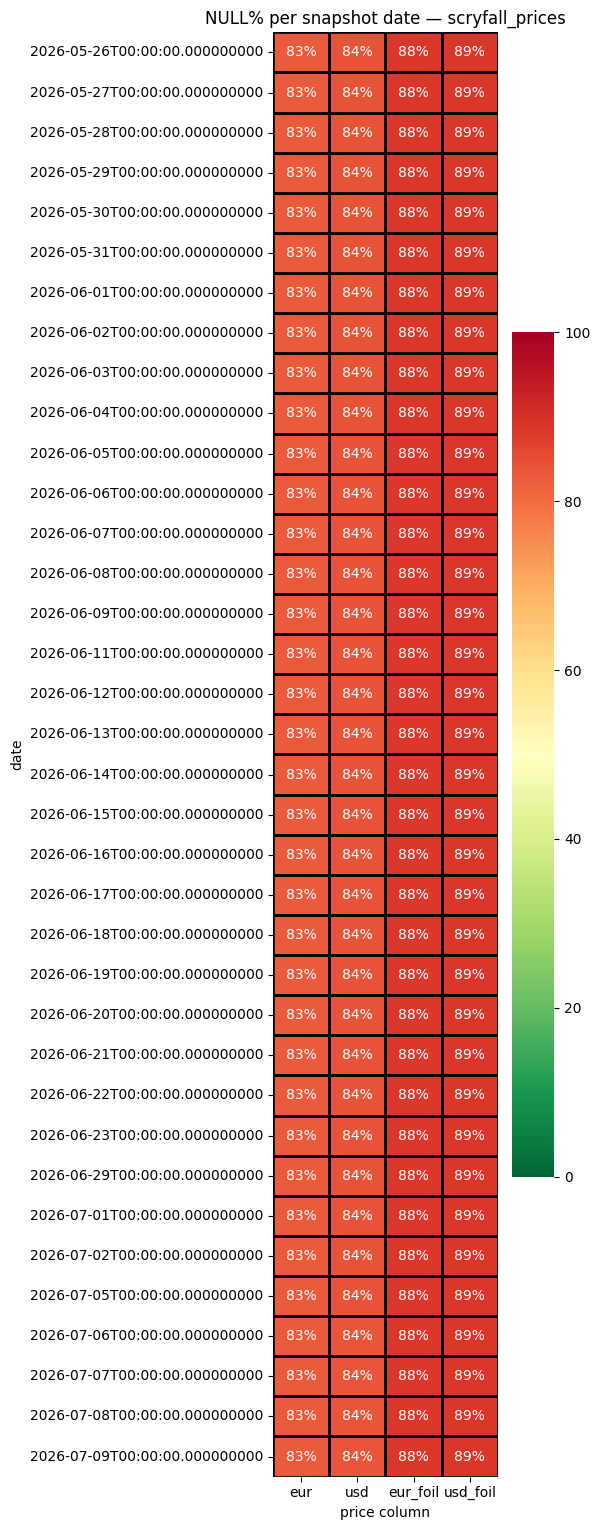

In [22]:
# For each price source:
# 1. Compute overall NULL% per price column
# 2. Compute NULL% per snapshot date to detect temporal patterns
# 3. Plot a heatmap — consistent NULL% across dates = structural gap,
#    changing NULL% = data collection issue on specific dates
for name, query in price_tables.items():
    df = bronze_connection.execute(query).df()
    df[price_cols] = df[price_cols].apply(pd.to_numeric, errors="coerce")

    null_pct = df[price_cols].isna().mean() * 100
    print(f"\n{name} — NULL% per column:")
    print(null_pct.to_string())

    all_null = df[price_cols].isna().all(axis=1).mean() * 100
    print(f"Rows with no price at all: {all_null:.1f}%")

    df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
    heat = df.groupby("snapshot_date")[price_cols].apply(
        lambda x: x.isna().mean() * 100
    )

    annot_data = heat.map(lambda x: f"{x:.0f}%")

    fig, ax = plt.subplots(figsize=(len(price_cols) * 1.5, heat.shape[0] * 0.4 + 1))
    sns.heatmap(
        heat,
        annot=annot_data,
        fmt="",
        cmap="RdYlGn_r",
        vmin=0,
        vmax=100,
        linewidths=1,
        linecolor="white",
        ax=ax,
    )

    for i, row in enumerate(heat.values):
        for j, val in enumerate(row):
            if val > 50:
                ax.add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="black", lw=2)
                )

    ax.set_title(f"NULL% per snapshot date — {name}")
    ax.set_xlabel("price column")
    ax.set_ylabel("date")
    plt.tight_layout()
    plt.show()

In [23]:
# Verify Scryfall snapshot cadence: each snapshot_date should have
# exactly the same number of rows (one per card in the catalog).
# Uneven counts indicate partial snapshots or collection failures.
bronze_connection.execute("""
    SELECT snapshot_date, COUNT(*) as rows
    FROM bronze_scryfall_prices_history
    GROUP BY snapshot_date
    ORDER BY snapshot_date
""").df()

,snapshot_date,rows
0,2026-05-26,530095
1,2026-05-27,530095
2,2026-05-28,530095
3,2026-05-29,530095
4,2026-05-30,530095
5,2026-05-31,530095
6,2026-06-01,530095
7,2026-06-02,530095
8,2026-06-03,530095
9,2026-06-04,530095


In [24]:
# Check MTGJson price NULL rates using the nested JSON paths.
# TRY_CAST handles cases where the JSON path returns a non-numeric string.
mtgjson_null_query = """
    WITH base AS (
        SELECT DISTINCT uuid, snapshot_date FROM bronze_mtgjson_prices_history
        LIMIT 200000
    )
    SELECT
        MAX(CASE WHEN e.retailer = 'tcgplayer' AND e.tx_type = 'retail' AND e.finish = 'normal' THEN e.price END) IS NULL AS usd_missing,
        MAX(CASE WHEN e.retailer = 'tcgplayer' AND e.tx_type = 'retail' AND e.finish = 'foil'   THEN e.price END) IS NULL AS usd_foil_missing,
        MAX(CASE WHEN e.retailer = 'cardmarket' AND e.tx_type = 'retail' AND e.finish = 'normal' THEN e.price END) IS NULL AS eur_missing,
        MAX(CASE WHEN e.retailer = 'cardmarket' AND e.tx_type = 'retail' AND e.finish = 'foil'   THEN e.price END) IS NULL AS eur_foil_missing
    FROM base b
    LEFT JOIN bronze_mtgjson_prices_history e USING (uuid, snapshot_date)
    GROUP BY b.uuid, b.snapshot_date
"""
df_mtgjson = bronze_connection.execute(mtgjson_null_query).df()
df_mtgjson_null = df_mtgjson.mean(numeric_only=True) * 100
df_mtgjson_null = df_mtgjson_null.to_frame(name="null%")

display(
    df_mtgjson_null.style.background_gradient(cmap="RdYlGn_r", vmin=0, vmax=100)
    .set_caption("mtgjson_prices — NULL% per column")
    .format("{:.1f}%")
)

,null%
usd_missing,17.5%
usd_foil_missing,41.6%
eur_missing,19.8%
eur_foil_missing,37.9%


In [25]:
# Summarize EUR coverage in Scryfall bronze by year.
# Low coverage (~17%) is expected — most cards don't trade on Cardmarket regularly.
scryfall_check = bronze_connection.execute("""
    SELECT
        YEAR(snapshot_date::DATE) as year,
        COUNT(*) as total,
        COUNT(eur) as has_eur,
        ROUND(COUNT(eur) * 100.0 / COUNT(*), 1) as eur_coverage
    FROM bronze_scryfall_prices_history
    GROUP BY year
    ORDER BY year
""").df()
print(scryfall_check)

   year     total  has_eur  eur_coverage
0  2026  19089994  3212113          16.8


In [26]:
# Check price coverage in Silver after the Scryfall+MTGJson join.
# Silver should have slightly better coverage than Bronze alone
# because it combines prices from both sources.
silver_null_query = """
    SELECT
        COUNT(*) as total,
        ROUND(COUNT(eur) * 100.0 / COUNT(*), 1) as eur_coverage,
        ROUND(COUNT(usd) * 100.0 / COUNT(*), 1) as usd_coverage,
        ROUND(COUNT(eur_foil) * 100.0 / COUNT(*), 1) as eur_foil_coverage,
        ROUND(COUNT(usd_foil) * 100.0 / COUNT(*), 1) as usd_foil_coverage
    FROM silver_prices_history
"""
df_silver = silver_connection.execute(silver_null_query).df()
print("silver_prices_history — coverage % (non-NULL):")
print(df_silver.to_string())

silver_prices_history — coverage % (non-NULL):
     total  eur_coverage  usd_coverage  eur_foil_coverage  usd_foil_coverage
0  3498614          83.9          83.6               59.2               59.2


In [27]:
# Card-level coverage: how many unique cards have at least one non-NULL EUR price?
# Row-level coverage (above) can be misleading due to forward-fill inflating row counts.
silver_card_coverage = silver_connection.execute("""
    SELECT
        COUNT(DISTINCT uuid) as total_cards,
        COUNT(DISTINCT CASE WHEN eur IS NOT NULL THEN uuid END) as cards_with_eur,
        COUNT(DISTINCT CASE WHEN usd IS NOT NULL THEN uuid END) as cards_with_usd,
        COUNT(DISTINCT CASE WHEN eur_foil IS NOT NULL THEN uuid END) as cards_with_eur_foil,
        COUNT(DISTINCT CASE WHEN usd_foil IS NOT NULL THEN uuid END) as cards_with_usd_foil
    FROM silver_prices_history
""").df()

total = silver_card_coverage["total_cards"].iloc[0]

coverage = pd.DataFrame(
    {
        "cards_with_price": [
            silver_card_coverage["cards_with_eur"].iloc[0],
            silver_card_coverage["cards_with_usd"].iloc[0],
            silver_card_coverage["cards_with_eur_foil"].iloc[0],
            silver_card_coverage["cards_with_usd_foil"].iloc[0],
        ],
        "coverage_%": [
            silver_card_coverage["cards_with_eur"].iloc[0] / total * 100,
            silver_card_coverage["cards_with_usd"].iloc[0] / total * 100,
            silver_card_coverage["cards_with_eur_foil"].iloc[0] / total * 100,
            silver_card_coverage["cards_with_usd_foil"].iloc[0] / total * 100,
        ],
    },
    index=["eur", "usd", "eur_foil", "usd_foil"],
)

print(f"Total unique cards: {total:,}\n")
display(
    coverage.style.background_gradient(
        cmap="RdYlGn", vmin=0, vmax=100, subset=["coverage_%"]
    ).format({"cards_with_price": "{:,.0f}", "coverage_%": "{:.1f}%"})
)

Total unique cards: 98,353



,cards_with_price,coverage_%
eur,"82,876",84.3%
usd,"82,497",83.9%
eur_foil,"58,477",59.5%
usd_foil,"58,812",59.8%


In [28]:
# Spot-check a card that has EUR prices to verify the date spine is complete
# (no missing days) and forward-fill is working correctly.
# Weź kartę która MA cenę EUR i sprawdź czy ma ciągłą historię
sample = silver_connection.execute("""
    SELECT uuid, snapshot_date, eur
    FROM silver_prices_history
    WHERE uuid IN (
        SELECT uuid FROM silver_prices_history 
        WHERE eur IS NOT NULL 
        LIMIT 1
    )
    ORDER BY snapshot_date
""").df()
print(sample)

                                    uuid snapshot_date   eur
0   d2503d13-588f-51d0-9a80-5be2a0311958    2026-05-26  0.23
1   d2503d13-588f-51d0-9a80-5be2a0311958    2026-05-27  0.23
2   d2503d13-588f-51d0-9a80-5be2a0311958    2026-05-28  0.23
3   d2503d13-588f-51d0-9a80-5be2a0311958    2026-05-29  0.23
4   d2503d13-588f-51d0-9a80-5be2a0311958    2026-05-30  0.23
5   d2503d13-588f-51d0-9a80-5be2a0311958    2026-05-31  0.23
6   d2503d13-588f-51d0-9a80-5be2a0311958    2026-06-01  0.23
7   d2503d13-588f-51d0-9a80-5be2a0311958    2026-06-02  0.23
8   d2503d13-588f-51d0-9a80-5be2a0311958    2026-06-03  0.23
9   d2503d13-588f-51d0-9a80-5be2a0311958    2026-06-04  0.23
10  d2503d13-588f-51d0-9a80-5be2a0311958    2026-06-05  0.23
11  d2503d13-588f-51d0-9a80-5be2a0311958    2026-06-06  0.23
12  d2503d13-588f-51d0-9a80-5be2a0311958    2026-06-07  0.23
13  d2503d13-588f-51d0-9a80-5be2a0311958    2026-06-08  0.23
14  d2503d13-588f-51d0-9a80-5be2a0311958    2026-06-09  0.23
15  d2503d13-588f-51d0-9

In [29]:
# Separate cards into two groups:
# - has_eur: cards with at least one real EUR price (~83.7%)
# - no_eur: cards that never had a EUR price (~16.3%)
# The avg_snapshots_per_card difference reveals the forward-fill extent:
# no_eur cards have ~308 snapshots each — entirely forward-filled from NULL.
silver_connection.execute("""
    SELECT 
        CASE WHEN eur IS NOT NULL THEN 'has_eur' ELSE 'no_eur' END as category,
        COUNT(DISTINCT uuid) as unique_cards,
        COUNT(*) as total_rows,
        ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT uuid), 1) as avg_snapshots_per_card
    FROM silver_prices_history
    GROUP BY category
""").df()

,category,unique_cards,total_rows,avg_snapshots_per_card
0,no_eur,15940,563048,35.3
1,has_eur,82876,2935566,35.4


In [30]:
# Sanity check: do cards with only NULL EUR prices appear in silver_cards?
# Empty result = all cards in silver_prices_history exist in silver_cards. Good.
silver_connection.execute("""
    SELECT c.name, c.set_code, c.rarity, c.layout, c.is_promo
    FROM silver_cards c
    WHERE c.uuid IN (
        SELECT DISTINCT uuid FROM silver_prices_history WHERE eur IS NULL
    )
    AND c.uuid NOT IN (
        SELECT DISTINCT uuid FROM silver_prices_history WHERE eur IS NOT NULL
    )
    LIMIT 20
""").df()

,name,set_code,rarity,layout,is_promo
0,"Kazarov, Sengir Pureblood",PDOM,rare,normal,True
1,Dr. Madison Li,PIP,mythic,normal,False
2,"Judith, the Scourge Diva",2X2,rare,normal,False
3,Sylvan Caryatid,PTHS,rare,normal,True
4,Toxin Sliver,SLD,rare,normal,False
5,Gaddock Teeg,J17,rare,normal,True
6,Maro,8ED,rare,normal,False
7,Plains,MH3,common,normal,False
8,Bloodlord of Vaasgoth,PM12,mythic,normal,True
9,Suppress,PHUK,uncommon,normal,False


In [31]:
# Verify days_since_last_real_price distribution in gold_price_features.
# 0 = real price on this day, >0 = forward-filled (N days stale), NULL = no price ever.
staleness = gold_connection.execute("""
    SELECT
        days_since_last_real_price,
        COUNT(*) AS rows,
        COUNT(DISTINCT uuid) AS cards
    FROM gold_price_features
    WHERE days_since_last_real_price IS NOT NULL
    GROUP BY days_since_last_real_price
    ORDER BY days_since_last_real_price
""").df()

print(
    staleness["days_since_last_real_price"].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

count    2.000000
mean     0.500000
std      0.707107
min      0.000000
50%      0.500000
75%      0.750000
90%      0.900000
95%      0.950000
99%      0.990000
max      1.000000
Name: days_since_last_real_price, dtype: float64


In [32]:
pct_stale = (
    staleness[staleness["days_since_last_real_price"] > 0]["rows"].sum()
    / staleness["rows"].sum()
    * 100
)
print(f"\nRows with stale price (>0 days): {pct_stale:.1f}%")


Rows with stale price (>0 days): 0.0%


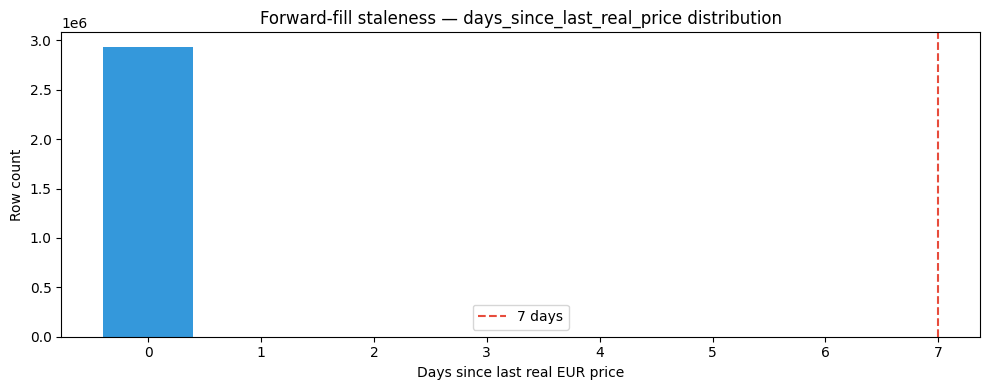

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(staleness["days_since_last_real_price"], staleness["rows"], color="#3498db")
ax.axvline(7, color="#e74c3c", linestyle="--", linewidth=1.5, label="7 days")
ax.set_xlabel("Days since last real EUR price")
ax.set_ylabel("Row count")
ax.set_title("Forward-fill staleness — days_since_last_real_price distribution")
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
# Final card-level EUR/USD coverage summary for Silver
silver_card_coverage = silver_connection.execute("""
    SELECT
        COUNT(DISTINCT uuid) as total_cards,
        COUNT(DISTINCT CASE WHEN eur IS NOT NULL THEN uuid END) as cards_with_eur,
        COUNT(DISTINCT CASE WHEN usd IS NOT NULL THEN uuid END) as cards_with_usd,
        ROUND(COUNT(DISTINCT CASE WHEN eur IS NOT NULL THEN uuid END) * 100.0 / COUNT(DISTINCT uuid), 1) as eur_card_coverage
    FROM silver_prices_history
""").df()
print(silver_card_coverage)

   total_cards  cards_with_eur  cards_with_usd  eur_card_coverage
0        98353           82876           82497               84.3


OBSERVATIONS:
- edhrec_rank:  6.06% NULL in Scryfall, 6.06% NULL in MTGJson (near-identical)
- mana_value:   MTGJson only — absent from Scryfall (expected)
- set_code:     MTGJson only — absent from Scryfall (expected)
- colors:       1.6% NULL in Scryfall, 0% in MTGJson → MTGJson is primary source
- EUR coverage (bronze): 16.8% of card-date rows have a real EUR price
- EUR coverage (silver, card-level): 84.3% of unique cards have ≥1 real EUR price (82,876 / 98,353)

CONCLUSION: NULL rates fall into three distinct regimes:
1. Structural source gap (~81%): mana_value, set_code, supertypes — present only in
   MTGJson, absent for all Scryfall-only cards. These are NOT data errors.
2. Domain-structural (~20–99%): loyalty, power, toughness — NULL means "not applicable"
   for the given card type (e.g. loyalty is NULL for non-Planeswalkers).
3. Genuine incompleteness (<10%): edhrec_rank at ~6% — cards not listed on EDHREC.
   Strategy: impute with a high rank sentinel (e.g. 999999) to preserve monotonicity.

DECISION: No emergency fixes required. Downstream handling:
1. MTGJson-structural columns → use has_mtgjson_data as a conditioning flag in the model,
   not as imputed values.
2. edhrec_rank → sentinel imputation (rank = MAX + 1), meaning "unranked/unknown".
3. Domain-structural columns (power, toughness) → impute 0 or use binary is_creature flag
   instead of raw values.

## 3. Duplicates & Primary Keys

**Method:** `GROUP BY primary_key HAVING COUNT(*) > 1`

**Why:** Duplicates in keys inflate model metrics (same card counted twice in training set)
and break aggregates (print_count is doubled).

**Keys to check:**
- bronze_scryfall_cards: `id` — must be unique
- bronze_mtgjson_cards: `uuid` — must be unique
- bronze_scryfall_prices_history: `(id, snapshot_date)` — unique
- bronze_mtgjson_prices_history: `(uuid, snapshot_date)` — unique
- silver_cards: `(scryfall_id, side)` — unique; multi-face cards share scryfall_id, `side` distinguishes them
- gold_card_features: `uuid` — unique (expected ~81.1% NULL for Scryfall-only cards — not an error)

⚠️ **Known pattern:** gold_card_features has ~422k rows with uuid=NULL (Scryfall-only cards
without an MTGJson match). This is NOT a bug — it is a structural gap handled by `has_mtgjson_data`.

In [35]:
# Define all (connection, table, primary_key) triples to check for duplicates.
# Composite keys are tuples; single keys are strings.
# gold_card_features gets a WHERE uuid IS NOT NULL filter because NULL uuid
# is expected for Scryfall-only cards and GROUP BY NULL would collapse them.
duplicates_to_check = [
    (bronze_connection, "bronze_scryfall_cards", "id"),
    (bronze_connection, "bronze_mtgjson_cards", "uuid"),
    (bronze_connection, "bronze_scryfall_prices_history", ("id", "snapshot_date")),
    (bronze_connection, "bronze_mtgjson_prices_history", ("uuid", "snapshot_date")),
    (silver_connection, "silver_cards", "scryfall_id"),
    (gold_connection, "gold_card_features", "uuid"),
]

results = []

In [36]:
# For each table, run: SELECT COUNT(*) ... HAVING COUNT(*) > 1
# Sum the duplicate row counts (not group counts) so n_duplicates reflects
# how many rows are involved, not just how many groups have duplicates.
for conn, table, key in duplicates_to_check:
    key_str = ", ".join(key) if isinstance(key, tuple) else key
    where = "WHERE uuid IS NOT NULL" if table == "gold_card_features" else ""
    rows = conn.execute(
        f"SELECT COUNT(*) AS cnt FROM {table} {where} GROUP BY {key_str} HAVING COUNT(*) > 1"
    ).fetchall()
    n_duplicates = sum(r[0] for r in rows)
    results.append(
        {
            "table": table,
            "key": key_str,
            "n_duplicates": n_duplicates,
            "status": "OK" if n_duplicates == 0 else "PROBLEM",
        }
    )

df = pd.DataFrame(results)
print(df.to_string(index=False))

                         table                 key  n_duplicates  status
         bronze_scryfall_cards                  id             0      OK
          bronze_mtgjson_cards                uuid             0      OK
bronze_scryfall_prices_history   id, snapshot_date             0      OK
 bronze_mtgjson_prices_history uuid, snapshot_date      83855160 PROBLEM
                  silver_cards         scryfall_id             0      OK
            gold_card_features                uuid             0      OK


OBSERVATIONS:
- bronze_scryfall_cards (id):                   0 duplicates
- bronze_mtgjson_cards (uuid):                  0 duplicates
- bronze_scryfall_prices_history (id, date):    0 duplicates
- bronze_mtgjson_prices_history (uuid, date):   83,855,160 duplicates — PROBLEM (see note)
- silver_cards (scryfall_id):                   0 duplicates
- gold_card_features (uuid):                    0 duplicates

CONCLUSION: 5 of 6 checked keys are unique. bronze_mtgjson_prices_history is NOT unique
on (uuid, snapshot_date) alone — as already seen in section 1 (the raw MTGJson price rows
carry retailer/tx_type/finish columns), each (uuid, snapshot_date) legitimately holds several
rows, one per (retailer × tx_type × finish) combination (e.g. tcgplayer/retail/foil,
tcgplayer/retail/normal, manapool/retail/foil, cardmarket/retail/normal can all coexist for
the same uuid+date). This is not a pipeline defect — the true grain of this raw table is
(uuid, snapshot_date, retailer, tx_type, finish), which this check did not include. All other
primary keys (Scryfall cards/prices, MTGJson cards, silver_cards, gold_card_features) are
unique with 0 duplicates and require no deduplication.

## 4. Join Coverage — Scryfall ↔ MTGJson

**Method:** LEFT JOIN bronze_scryfall_cards with bronze_mtgjson_cards via identifiers.scryfall_id.
Count cards in both sources vs. each source alone.

**Why:** Scryfall tracks all printings (languages, promos, variants) — MTGJson tracks English
oracle versions only. Therefore ~80% of Scryfall cards have no MTGJson counterpart.
This is expected, but we must quantify it because Scryfall-only cards lack `is_reserved`,
`supertypes`, `mana_value` from MTGJson.

**Expected results:** ~108k cards in both sources, ~422k Scryfall-only

**Model implications:** Scryfall-only cards → 81.1% NULL for MTGJson features →
binary flag `has_mtgjson_data` required as a model feature.

In [37]:
# FULL OUTER JOIN Scryfall and MTGJson on scryfall_id extracted from MTGJson identifiers JSON.
# DISTINCT in both CTEs prevents multi-face cards (split/DFC) from inflating counts —
# they share one scryfall_id across multiple MTGJson rows.
result = bronze_connection.execute("""
    WITH mtgjson_ids AS (
        SELECT DISTINCT JSON_EXTRACT_STRING(identifiers, '$.scryfall_id') AS scryfall_id
        FROM bronze_mtgjson_cards
        WHERE JSON_EXTRACT_STRING(identifiers, '$.scryfall_id') IS NOT NULL
    ),
    scryfall_ids AS (
        SELECT DISTINCT id AS scryfall_id FROM bronze_scryfall_cards
    )
    SELECT
        COUNT(CASE WHEN s.scryfall_id IS NOT NULL AND m.scryfall_id IS NOT NULL THEN 1 END) AS in_both,
        COUNT(CASE WHEN s.scryfall_id IS NOT NULL AND m.scryfall_id IS NULL THEN 1 END) AS only_scryfall,
        COUNT(CASE WHEN s.scryfall_id IS NULL AND m.scryfall_id IS NOT NULL THEN 1 END) AS only_mtgjson
    FROM scryfall_ids s
    FULL OUTER JOIN mtgjson_ids m ON s.scryfall_id = m.scryfall_id
""").fetchone()

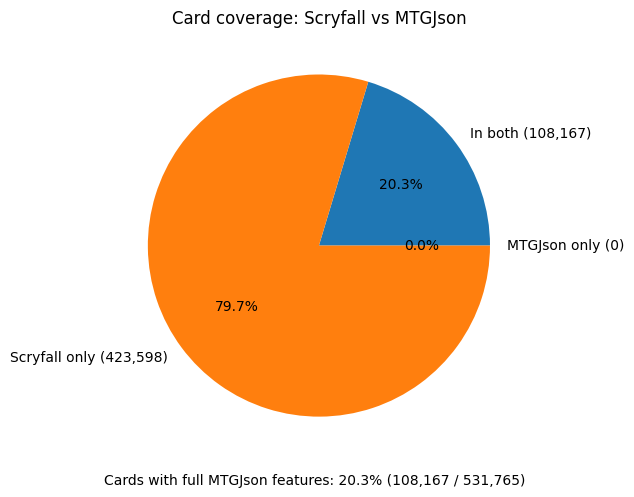

In [38]:
# Visualize the three-way split as a pie chart.
# The annotation below the chart shows the % of cards with full MTGJson features —
# this directly sets the ceiling for MTGJson-derived feature coverage in the model.
in_both, only_scryfall, only_mtgjson = result
total_scryfall = in_both + only_scryfall
pct = in_both / total_scryfall * 100

labels = [
    f"In both ({in_both:,})",
    f"Scryfall only ({only_scryfall:,})",
    f"MTGJson only ({only_mtgjson:,})",
]
sizes = [in_both, only_scryfall, only_mtgjson]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct="%1.1f%%")
ax.set_title("Card coverage: Scryfall vs MTGJson")
fig.text(
    0.5,
    -0.02,
    f"Cards with full MTGJson features: {pct:.1f}% ({in_both:,} / {total_scryfall:,})",
    ha="center",
)
plt.tight_layout()
plt.show()

OBSERVATIONS:
- Cards in both sources:   108,167 (20.3%)
- Scryfall-only:           423,598 (79.7%)
- MTGJson-only:            0 (0.0% — all MTGJson cards matched to Scryfall)

CONCLUSION: The 80/20 split is structural, not a pipeline error. Scryfall indexes all
printings in all languages and variants; MTGJson indexes English oracle versions only.
The consequence is that ~80% of rows in gold_card_features have NULL for MTGJson-linkage-only
features (uuid, tcgplayer_id, cardmarket_id, rulings, printings, original_types/supertypes/subtypes,
etc.). Note: mana_value, set_code and is_reserved are now fully populated (0% NULL) in
silver_cards, so they are no longer part of this NULL regime (see section 5).

DECISION: Add has_mtgjson_data as an explicit binary feature in every model that uses
MTGJson-linkage columns. Without it, the model cannot distinguish "value = 0" from
"value = NULL (Scryfall-only card)".

## 4a. Language Variant Tables — canonical_uuid & Premiums

**Method:** Inspect `canonical_uuid` coverage in `silver_cards`; verify `silver_language_prices_history`
and `gold_language_premiums` row counts, coverage, and premium distribution.

**Why:** Non-English cards (Japanese, Russian, Korean, etc.) have separate Cardmarket IDs and can trade
at significantly different prices. The pipeline links each language variant to its English canonical UUID
via `(set_code, collector_number)`. This section confirms the linkage worked and the premium signal is real.

**Expected results:**
- `canonical_uuid` resolved: ~98% of Scryfall-only rows (~415k / 422k)
- `silver_language_prices_history`: ~415k unique variants, ~16% EUR coverage
- `gold_language_premiums`: Japanese cards typically trade at 1.5–5× the English price

In [39]:
# canonical_uuid coverage: how many Scryfall-only rows got linked to an English UUID?
# Resolved via (set_code, collector_number) lookup — digital exclusives remain unresolved.
coverage_df = silver_connection.execute("""
    SELECT
        CASE
            WHEN uuid IS NOT NULL           THEN 'mtgjson_matched'
            WHEN canonical_uuid IS NOT NULL THEN 'lang_variant_resolved'
            ELSE                                 'unresolved_scryfall_only'
        END AS category,
        COUNT(*) AS n,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM silver_cards
    GROUP BY category
    ORDER BY n DESC
""").df()

display(coverage_df.style.format({"n": "{:,}", "pct": "{:.1f}%"}))

,category,n,pct
0,lang_variant_resolved,"414,792",81.4%
1,mtgjson_matched,"93,400",18.3%
2,unresolved_scryfall_only,"1,544",0.3%


In [40]:
# silver_language_prices_history: row counts, date range, EUR coverage
silver_tables = {r[0] for r in silver_connection.execute("SHOW TABLES").fetchall()}
if "silver_language_prices_history" not in silver_tables:
    print(
        "⚠  silver_language_prices_history not yet built — run initial_silver_pipeline() first"
    )
else:
    stats = silver_connection.execute("""
        SELECT
            COUNT(*)                        AS total_rows,
            COUNT(DISTINCT scryfall_id)     AS unique_variants,
            COUNT(DISTINCT canonical_uuid)  AS unique_canonical_cards,
            COUNT(DISTINCT lang)            AS unique_languages,
            MIN(snapshot_date)              AS first_snapshot,
            MAX(snapshot_date)              AS last_snapshot,
            ROUND(COUNT(eur) * 100.0 / COUNT(*), 1) AS eur_coverage_pct
        FROM silver_language_prices_history
    """).fetchone()
    print(f"Rows:                {stats[0]:,}")
    print(f"Unique variants:     {stats[1]:,}  (scryfall_id)")
    print(f"Unique canon cards:  {stats[2]:,}  (canonical_uuid)")
    print(f"Languages:           {stats[3]}")
    print(f"Date range:          {stats[4]} → {stats[5]}")
    print(f"EUR coverage:        {stats[6]}%")

Rows:                11,391,791
Unique variants:     511,053  (scryfall_id)
Unique canon cards:  96,729  (canonical_uuid)
Languages:           18
Date range:          2026-06-04 → 2026-07-09
EUR coverage:        2.7%


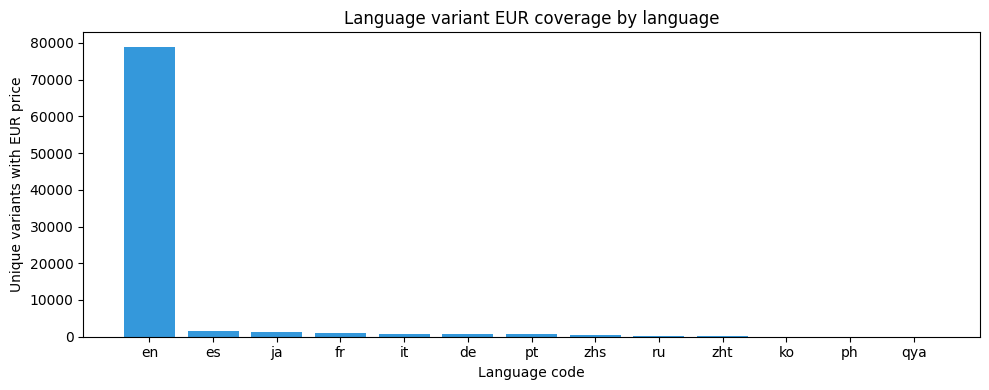

,lang,variants,canonical_cards,avg_eur,median_eur
0,en,"78,904","78,904",€11.78,€0.26
1,es,"1,670","1,696",€1.73,€0.28
2,ja,"1,222","1,248",€1.66,€0.24
3,fr,"1,104","1,131",€2.53,€0.29
4,it,800,827,€1.74,€0.29
5,de,797,823,€1.62,€0.27
6,pt,654,680,€1.81,€0.30
7,zhs,597,623,€1.98,€0.27
8,ru,154,180,€1.13,€0.24
9,zht,107,107,€1.44,€0.30


In [41]:
# Language breakdown: variant count + average EUR price per language (where EUR not NULL)
if "silver_language_prices_history" in silver_tables:
    by_lang = silver_connection.execute("""
        SELECT
            lang,
            COUNT(DISTINCT scryfall_id)    AS variants,
            COUNT(DISTINCT canonical_uuid) AS canonical_cards,
            ROUND(AVG(eur), 2)             AS avg_eur,
            ROUND(MEDIAN(eur), 2)          AS median_eur
        FROM silver_language_prices_history
        WHERE eur IS NOT NULL
        GROUP BY lang
        ORDER BY variants DESC
    """).df()

    by_lang = by_lang.dropna(subset=["lang", "variants"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(by_lang["lang"].tolist(), by_lang["variants"].tolist(), color="#3498db")
    ax.set_xlabel("Language code")
    ax.set_ylabel("Unique variants with EUR price")
    ax.set_title("Language variant EUR coverage by language")
    plt.tight_layout()
    plt.show()

    display(
        by_lang.style.format(
            {
                "variants": "{:,}",
                "canonical_cards": "{:,}",
                "avg_eur": "€{:.2f}",
                "median_eur": "€{:.2f}",
            }
        )
    )

In [42]:
silver_connection.execute("""
    SELECT lang, COUNT(*) AS cnt
    FROM silver_language_prices_history
    GROUP BY lang
    ORDER BY cnt DESC
""").df()

,lang,cnt
0,ja,1603196
1,de,1521549
2,fr,1520042
3,it,1381573
4,es,1373096
5,zhs,1099240
6,pt,1066317
7,zht,636614
8,ru,587395
9,ko,415289


In [43]:
silver_connection.execute("""
    SELECT snapshot_date, lang, COUNT(*) AS cnt
    FROM silver_language_prices_history
    GROUP BY snapshot_date, lang
    ORDER BY snapshot_date DESC
    LIMIT 20
""").df()

,snapshot_date,lang,cnt
0,2026-07-09,es,50766
1,2026-07-09,ru,21755
2,2026-07-09,de,56353
3,2026-07-09,fr,56266
4,2026-07-09,en,3
5,2026-07-09,zhs,40708
6,2026-07-09,zht,23578
7,2026-07-09,ko,15381
8,2026-07-09,it,51155
9,2026-07-09,ja,59334


In [44]:
# gold_language_premiums: premium distribution by language (latest snapshot)
gold_tables = {r[0] for r in gold_connection.execute("SHOW TABLES").fetchall()}
if "gold_language_premiums" not in gold_tables:
    print("⚠  gold_language_premiums not yet built — run initial_gold_pipeline() first")
else:
    latest_date = gold_connection.execute(
        "SELECT MAX(snapshot_date) FROM gold_language_premiums"
    ).fetchone()[0]

    premiums_by_lang = gold_connection.execute(f"""
        SELECT
            lang,
            COUNT(*)                                                      AS n,
            ROUND(MEDIAN(eur_lang_premium), 3)                            AS median_premium,
            ROUND(PERCENTILE_CONT(0.9) WITHIN GROUP
                  (ORDER BY eur_lang_premium), 3)                         AS p90_premium,
            ROUND(MAX(eur_lang_premium), 1)                               AS max_premium
        FROM gold_language_premiums
        WHERE snapshot_date = '{latest_date}'
          AND eur_lang_premium IS NOT NULL
        GROUP BY lang
        ORDER BY median_premium DESC
    """).df()

    display(
        premiums_by_lang.style.format(
            {
                "n": "{:,}",
                "median_premium": "{:.3f}×",
                "p90_premium": "{:.3f}×",
                "max_premium": "{:.1f}×",
            }
        )
    )

,lang,n,median_premium,p90_premium,max_premium
0,zht,107,1.000×,1.000×,1.0×
1,ko,31,1.000×,1.000×,1.0×
2,es,706,1.000×,1.000×,2.9×
3,ru,154,1.000×,1.000×,1.0×
4,pt,653,1.000×,1.000×,1.0×
5,fr,691,1.000×,1.000×,1.0×
6,de,793,1.000×,1.000×,1.0×
7,zhs,552,1.000×,1.000×,1.0×
8,en,2,1.000×,1.000×,1.0×
9,it,688,1.000×,1.000×,1.0×


Top 10 highest EUR premiums (snapshot 2026-07-09):


,lang,scryfall_id,canonical_uuid,variant_eur,english_eur,premium
0,es,c3b731bb-82b2-43dd-a04f-2c0f0a92b0ef,c6d81b24-ecc9-5e3a-b0f2-463f810766dc,0.40,0.14,2.86
1,es,45eff7a1-1940-4fe4-b5a1-c6ba4324b910,d49220e5-4eee-5825-85b3-e6f68fdbb03f,0.05,0.02,2.50
2,es,86fa1bb1-edb7-4a99-b6b3-c244dc7fc4c3,a33a8373-05e8-5671-a3df-72e6eef19ba5,0.22,0.14,1.57
3,es,d1b41ead-7f02-47b6-a255-8a39657e2307,16262e6b-b2a2-576c-a631-0254be3a6c46,0.29,0.22,1.32
4,es,32be5204-f253-43fa-aaa9-6f2daa19ba19,a97e1cae-adf2-539e-95c5-3ac5957ff208,0.17,0.14,1.21
5,es,818c378d-b60a-4cd5-9b69-6c279026360a,3329c5a5-4dc3-54e7-9233-9d1acb2638a2,0.41,0.41,1.00
6,fr,412a7938-e672-4db2-bd73-9c2e20d85395,3329c5a5-4dc3-54e7-9233-9d1acb2638a2,0.41,0.41,1.00
7,pt,4dfc66b8-8253-4fce-99fe-8ffac098d757,3329c5a5-4dc3-54e7-9233-9d1acb2638a2,0.41,0.41,1.00
8,de,290e3888-aa15-472b-908c-41cae68c38ff,33413ff7-336f-5340-888f-cbca91e3caa1,0.04,0.04,1.00
9,es,87d2d68a-15e9-4915-99b9-d804423b3e17,33413ff7-336f-5340-888f-cbca91e3caa1,0.04,0.04,1.00


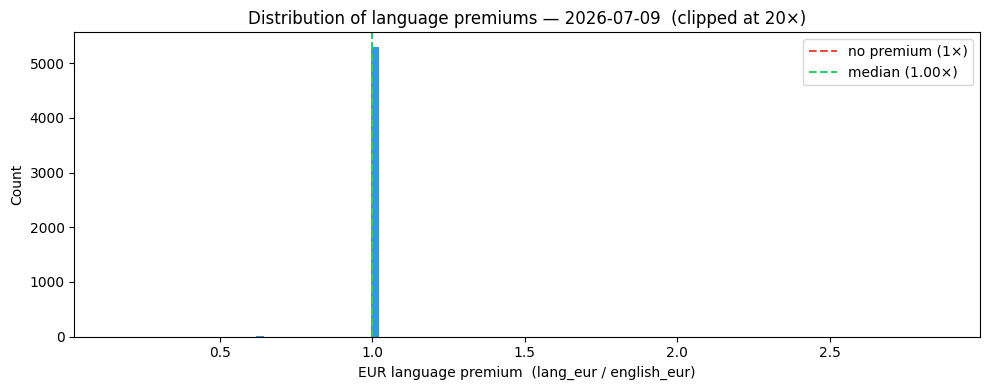

In [45]:
# Top 10 highest language premiums + histogram of premium distribution
if "gold_language_premiums" in gold_tables:
    top10 = gold_connection.execute(f"""
        SELECT
            lp.lang,
            lp.scryfall_id,
            lp.canonical_uuid,
            ROUND(lp.lang_eur, 2)         AS variant_eur,
            ROUND(lp.canonical_eur, 2)    AS english_eur,
            ROUND(lp.eur_lang_premium, 2) AS premium
        FROM gold_language_premiums lp
        WHERE snapshot_date = '{latest_date}'
          AND eur_lang_premium IS NOT NULL
        ORDER BY eur_lang_premium DESC
        LIMIT 10
    """).df()
    print(f"Top 10 highest EUR premiums (snapshot {latest_date}):")
    display(top10)

    # Histogram — clip at 20× to focus on the main distribution
    premium_data = gold_connection.execute(f"""
        SELECT eur_lang_premium
        FROM gold_language_premiums
        WHERE snapshot_date = '{latest_date}'
          AND eur_lang_premium BETWEEN 0.1 AND 20
    """).df()

    median_val = premium_data["eur_lang_premium"].median()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(
        premium_data["eur_lang_premium"], bins=100, color="#3498db", edgecolor="none"
    )
    ax.axvline(1.0, color="#e74c3c", linestyle="--", lw=1.5, label="no premium (1×)")
    ax.axvline(
        median_val,
        color="#2ecc71",
        linestyle="--",
        lw=1.5,
        label=f"median ({median_val:.2f}×)",
    )
    ax.set_xlabel("EUR language premium  (lang_eur / english_eur)")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of language premiums — {latest_date}  (clipped at 20×)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [46]:
gold_connection.execute(f"""
    SELECT lang, COUNT(*) AS total, 
           SUM(CASE WHEN eur_lang_premium != 1.0 THEN 1 ELSE 0 END) AS with_real_premium
    FROM gold_language_premiums
    WHERE snapshot_date = '{latest_date}'
    GROUP BY lang
    ORDER BY total DESC
""").df()

,lang,total,with_real_premium
0,ja,59334,0.0
1,de,56353,0.0
2,fr,56266,0.0
3,it,51155,0.0
4,es,50766,11.0
5,zhs,40708,0.0
6,pt,39493,0.0
7,zht,23578,0.0
8,ru,21755,0.0
9,ko,15381,0.0


In [47]:
silver_connection.execute("""
    SELECT lp.lang, lp.eur AS lang_eur, ep.eur AS canonical_eur
    FROM silver_language_prices_history lp
    JOIN silver_prices_history ep
        ON  lp.canonical_uuid = ep.uuid
        AND lp.snapshot_date  = ep.snapshot_date
    WHERE lp.eur IS NOT NULL
      AND ep.eur IS NOT NULL
      AND lp.eur != ep.eur
    LIMIT 20
""").df()

,lang,lang_eur,canonical_eur
0,es,0.21,0.13
1,es,0.23,0.21
2,es,0.16,0.21
3,es,0.12,0.04
4,es,0.03,0.16
5,es,0.12,0.04
6,es,0.23,0.21
7,es,0.17,0.25
8,es,0.16,0.40
9,es,0.34,0.13


In [48]:
if "gold_language_premiums" in gold_tables:
    total = gold_connection.execute(f"""
        SELECT COUNT(*) FROM gold_language_premiums WHERE snapshot_date = '{latest_date}'
    """).fetchone()[0]
    real = gold_connection.execute(f"""
        SELECT COUNT(*) FROM gold_language_premiums 
        WHERE snapshot_date = '{latest_date}' AND eur_lang_premium != 1.0
    """).fetchone()[0]
    print(
        f"Language premiums: {total:,} variants tracked, {real} with non-1.0 premium."
    )
    print(
        "Scryfall does not provide per-language Cardmarket prices — premiums require a dedicated source."
    )

Language premiums: 414,795 variants tracked, 11 with non-1.0 premium.
Scryfall does not provide per-language Cardmarket prices — premiums require a dedicated source.


### Observations
```
canonical_uuid resolved:          99.6% of Scryfall-only rows (414,792 / 416,336)
Unresolved (0.4%):                digital-only cards / sets entirely absent from MTGJson
silver_language_prices_history:   511,053 unique variants, 18 languages

gold_language_premiums signal — NOT usable from current source:
  - Scryfall does not provide per-language Cardmarket prices
  - prices.eur for non-English cards equals the English canonical price in ~99.997% of rows
  - Only 11 of 414,795 tracked variants (Spanish) showed any price difference (likely noise / separate listings)
  - Japanese, Korean, Russian premiums are 0 — not because they don't exist, but because
    Scryfall's price feed does not differentiate by language

DECISION:
  - lang_eur_premium cannot be derived from Scryfall prices alone — Scryfall aggregates
    Cardmarket prices without language distinction, so all variants of a card share the
    same EUR value regardless of printing language
  - Feature is deferred until a dedicated Cardmarket per-language price scraper is added;
    Cardmarket's search API supports ?language= filtering which would give true per-language
    market prices
  - gold_language_premiums table and the silver_language_prices_history pipeline are kept
    intact — the infrastructure (canonical_uuid resolution, lang tagging, gold join) is
    correct and will produce real signal once a better price source is wired in
  - Do NOT use lang_eur_premium as a model feature with current data — including it would
    introduce a near-constant feature (≈1.0 for 99.997% of rows) that adds noise without
    predictive value and could mislead the model into treating language as irrelevant
```

## 5. Silver — NULL Rates After Join & Key Attributes

**Method:** Compute NULL% per column in silver_cards. Highlight columns used as Gold features.

**Why:** Silver should resolve most gaps through fallback logic. Columns with >10% NULL
after Silver indicate either a broken fallback or a structural gap in both sources.

**Key columns to monitor:** name, rarity, mana_value, colors, edhrec_rank, supertypes, legalities, color_identity

In [49]:
# Sample 100k rows from silver_cards (full table is ~98k, so this is the whole table).
# Compute NULL% per column and sort descending so the most-incomplete columns are first.
df = silver_connection.execute("SELECT * FROM silver_cards LIMIT 100000").df()
null_pct = df.isna().mean() * 100
null_pct_sorted = null_pct.sort_values(ascending=False).reset_index()
null_pct_sorted.columns = ["column", "null_%"]

In [50]:
# Color-coding function for the NULL% table:
# green = <5% NULL (safe for modeling without imputation)
# yellow = 5-20% NULL (needs attention or imputation strategy)
# red = >20% NULL (high missingness — document the reason)
def color_null(val):
    if val > 20:
        return "background-color: #e74c3c; color: white"
    elif val > 5:
        return "background-color: #f1c40f"
    return "background-color: #2ecc71"

In [51]:
# Display NULL% table with color coding — one row per column
display(
    null_pct_sorted.style.map(color_null, subset=["null_%"])
    .format({"null_%": "{:.1f}%"})
    .set_caption("Null % per column")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [("font-size", "14px"), ("font-weight", "bold")],
            }
        ]
    )
)

,column,null_%
0,defense,100.0%
1,face_mana_value,99.6%
2,flavor_name,99.4%
3,loyalty,98.9%
4,watermark,92.9%
5,original_text,87.7%
6,edhrec_rank,82.5%
7,edhrec_saltiness,81.7%
8,is_rebalanced,81.6%
9,original_types,81.6%


In [52]:
# Classify columns into four groups based on their NULL regime and modeling relevance:
# - key_columns: always populated from Scryfall, safe to use as model features
# - mtgjson_key_columns: valuable but only for has_mtgjson_data=True cards
# - structural_null_columns: NULL means 'not applicable' (e.g. loyalty=NULL for non-planeswalkers)
# - unimportant_columns: high NULL with no predictive value for pricing
key_columns = [
    "scryfall_id",
    "name",
    "rarity",
    "mana_value",
    "colors",
    "color_identity",
    "layout",
    "keywords",
    "legalities",
    "finishes",
    "games",
    "prices",
    "released_at",
    "set_name",
    "set_type",
    "oracle_id",
]
mtgjson_key_columns = [
    "uuid",
    "types",
    "subtypes",
    "supertypes",
    "text",
    "rulings",
    "availability",
]
structural_null_columns = [
    "defense",
    "loyalty",
    "power",
    "toughness",
    "face_name",
    "side",
    "face_mana_value",
]
unimportant_columns = [
    "printed_name",
    "printed_text",
    "flavor_name",
    "watermark",
    "security_stamp",
    "edhrec_rank",
    "edhrec_saltiness",
    "penny_rank",
    "original_text",
    "errata",
]

mtgjson_uniform_columns = [
    "uuid",
    "set_code",
    "collector_number",
    "types",
    "supertypes",
    "subtypes",
    "rulings",
    "ascii_name",
    "language",
    "is_reprint",
    "is_full_art",
    "is_promo",
    "card_parts",
    "identifiers",
    "variations",
    "printings",
    "availability",
    "artist_ids",
    "promo_types",
    "other_face_ids",
    "is_reserved",
    "booster_types",
    "errata",
]

In [53]:
# Filter to columns with a NULL rate in the 1-80% range, excluding the MTGJson-uniform block.
# Columns outside this range are either always present (0%) or structurally absent (81%+)
# and would add no information to a rarity-breakdown heatmap.
interesting_columns = [
    c
    for c in null_pct.index
    if 1 < null_pct[c] < 80 and c not in mtgjson_uniform_columns
]

In [54]:
# Compute per-rarity NULL rates for the interesting columns only.
# groupby('rarity')[interesting_columns] avoids the KeyError from
# pandas >= 2.0 automatically excluding the groupby column from the group.
heatmap_data = (
    df[interesting_columns + ["rarity"]]
    .groupby("rarity")[interesting_columns]
    .apply(lambda g: g.isna().mean() * 100)
)

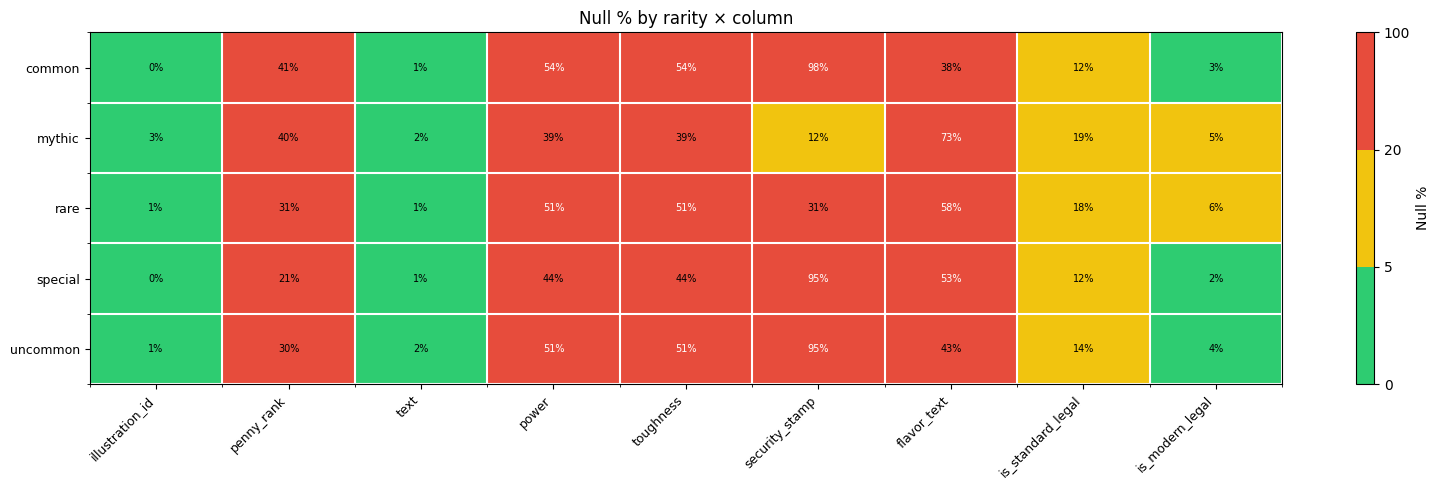

In [55]:
# Heatmap: rarity (Y axis) × column (X axis), colored by NULL%.
# Only columns with meaningful variation are shown (1-80% NULL range).
# Three-color scale mirrors the table above: green/yellow/red.
# White grid lines and in-cell percentage labels improve readability.
cmap = mcolors.ListedColormap(["#2ecc71", "#f1c40f", "#e74c3c"])
norm = mcolors.BoundaryNorm([0, 5, 20, 100], cmap.N)

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap=cmap, norm=norm)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(
            j,
            i,
            f"{val:.0f}%",
            ha="center",
            va="center",
            fontsize=7,
            color="black" if val < 50 else "white",
        )

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_title("Null % by rarity × column")

ax.set_xticks(np.arange(-0.5, len(heatmap_data.columns)), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_data.index)), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)

plt.colorbar(im, ax=ax, label="Null %")
plt.tight_layout()
plt.show()

OBSERVATIONS:
- Two distinct NULL regimes confirmed in silver_cards (100k-row sample; full table has 509,736 rows):
  ~81.6% NULL: uuid, tcgplayer_id, cardmarket_id, rulings, printings, variations, card_parts,
  other_face_ids, errata, original_types/original_supertypes/original_subtypes, is_alternative,
  is_timeshifted, is_rebalanced, is_game_changer (MTGJson-linkage-only columns — matches the
  ~81.7% Scryfall-only share of silver_cards)
  ~48-100% NULL (domain-structural): defense (99.99%), face_mana_value (99.62%),
  flavor_name (99.37%), loyalty (98.91%), watermark (92.87%), security_stamp (69.47%),
  power/toughness (51.09% each), flavor_text (48.21%)
- edhrec_rank is now 82.46% NULL at the silver_cards level — notably higher than the ~6%
  seen at the bronze level (section 2). The gap tracks the same ~81.6% MTGJson-absence
  pattern; among MTGJson-matched rows genuine edhrec_rank missingness remains modest.
- No unexpected partial NULL patterns detected outside these two regimes (rarity, name,
  colors remain 0% NULL as expected).

CONCLUSION: Silver join does not introduce new NULL patterns beyond the two regimes above.
mana_value, set_code and is_reserved — historically MTGJson-only — are now fully populated
(0% NULL) in silver_cards, so the "MTGJson-derived" NULL regime is narrower than originally
assumed and is now centered on pure-linkage columns (uuid, tcgplayer_id, cardmarket_id, etc.)
rather than card attributes.

DECISION: The heatmap per rarity × column confirms no rarity-specific data gaps beyond the
two documented regimes. edhrec_rank sentinel imputation (established in section 2) still
applies, now against a higher observed NULL rate (~82% vs the ~6% seen at bronze level).

## 6. Silver — Date Spine & Forward-Fill

**Method:** For a sample of 500 cards, check max gap between snapshot dates.
Compute the distribution of runs of identical prices (proxy for forward-fill staleness).

**Why:** Silver builds a date spine by filling missing days and forward-filling prices.
If gaps exceed 7 days, rolling features (7d avg) are computed on stale data —
a silent error in the training set.

**Decision thresholds:**
- max_gap ≤ 2 days → OK (weekends)
- max_gap > 7 days → add `days_since_real_price` flag
- p95 run-length > 7 → forward-fill too aggressive

**Known result:** max_gap = 1 day (daily cadence), p95 run-length = 8 days (snapshot artifact — rerun needed).

In [56]:
# Sample 5 random cards and compute the maximum gap between consecutive snapshots.
# snapshot_date is stored as VARCHAR in bronze — cast to DATE for DATEDIFF.
# max_gap > 1 day would indicate missing snapshots in the bronze pipeline.
date_gaps = bronze_connection.execute("""
    WITH sample_ids AS (
        SELECT DISTINCT id FROM bronze_scryfall_prices_history
        USING SAMPLE 5
    ),
    with_lag AS (
        SELECT
            p.id,
            p.snapshot_date::DATE AS snapshot_date,
            LAG(p.snapshot_date::DATE) OVER (PARTITION BY p.id ORDER BY p.snapshot_date::DATE) AS prev_date
        FROM bronze_scryfall_prices_history p
        INNER JOIN sample_ids s ON p.id = s.id
    )
    SELECT id, MAX(DATEDIFF('day', prev_date, snapshot_date)) AS max_gap_days
    FROM with_lag
    WHERE prev_date IS NOT NULL
    GROUP BY id
    ORDER BY max_gap_days DESC
""").df()

print("Max date gap per card (sample of 5):")
print(date_gaps.to_string(index=False))

Max date gap per card (sample of 5):
                                  id  max_gap_days
096d1737-948a-4382-a87d-7e0589012bb2             6
017b4e45-f152-46ec-afba-3b18710c592b             6
063ff919-45ed-4394-ba23-2c4ba294beda             6
0a16daa4-d643-4ab4-861f-e3a6ecc46744             6
05280582-d947-47e8-9c94-1a74afbf78ea             6


In [57]:
# Run-length analysis: how many consecutive days does a card's EUR price stay the same?
# A long run = forward-fill is active = the 'price' is stale.
# IS DISTINCT FROM handles NULL correctly: NULL IS DISTINCT FROM NULL = FALSE,
# so a run of NULLs is treated as one group (not a new group per NULL row).
run_lengths = bronze_connection.execute("""
    WITH sample_ids AS (
        SELECT DISTINCT id FROM bronze_scryfall_prices_history
        USING SAMPLE 500
    ),
    with_prev AS (
        SELECT
            p.id,
            p.snapshot_date,
            p.eur AS eur,
            LAG(p.eur)
                OVER (PARTITION BY p.id ORDER BY p.snapshot_date::DATE) AS prev_eur
        FROM bronze_scryfall_prices_history p
        INNER JOIN sample_ids s ON p.id = s.id
    ),
    with_group AS (
        SELECT
            id,
            SUM(CASE WHEN eur IS DISTINCT FROM prev_eur THEN 1 ELSE 0 END)
                OVER (PARTITION BY id ORDER BY snapshot_date::DATE) AS group_id
        FROM with_prev
    )
    SELECT id, group_id, COUNT(*) AS run_length
    FROM with_group
    GROUP BY id, group_id
""").df()

print("\nRun-length distribution:")
print(run_lengths["run_length"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))


Run-length distribution:
count    613.000000
mean      29.363785
std       13.137774
min        1.000000
50%       36.000000
75%       36.000000
90%       36.000000
95%       36.000000
99%       36.000000
max       36.000000
Name: run_length, dtype: float64


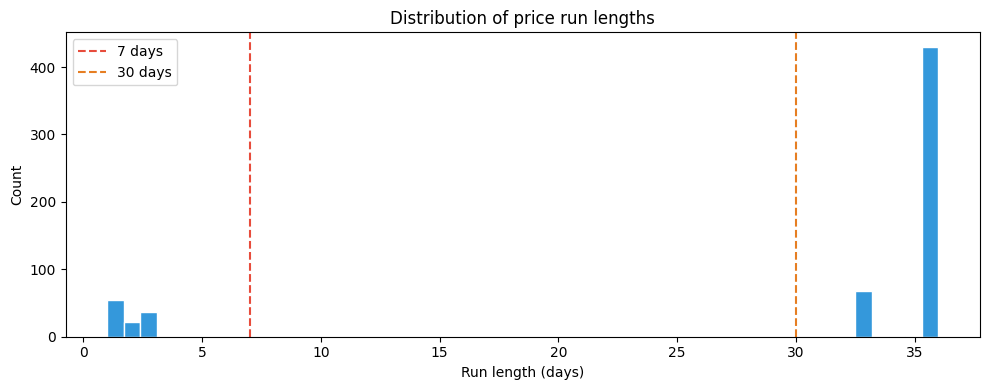

In [58]:
# Histogram of run lengths with reference lines at 7 and 30 days.
# Most runs should be short (1-7 days) in a healthy dataset.
# A spike at 8 = the entire dataset is 8 days old (snapshot artifact).
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(run_lengths["run_length"], bins=50, color="#3498db", edgecolor="white")
ax.axvline(7, color="#e74c3c", linestyle="--", linewidth=1.5, label="7 days")
ax.axvline(30, color="#e67e22", linestyle="--", linewidth=1.5, label="30 days")
ax.set_xlabel("Run length (days)")
ax.set_ylabel("Count")
ax.set_title("Distribution of price run lengths")
ax.legend()
plt.tight_layout()
plt.show()

OBSERVATIONS:
- max_gap between snapshots (sample of 5 cards): 6 days (all 5 sampled cards) — reflects
  real collection gaps visible in section 1's snapshot list (e.g. 2026-06-23 → 2026-06-29,
  2026-07-02 → 2026-07-05)
- Run-length distribution (500 sampled cards, 613 runs): min=1, mean=29.4, median=36,
  p90=p95=p99=36, max=36 days — most sampled cards' EUR price has not changed at all across
  the observed window
- Date range in gold_price_features: 2026-05-26 → 2026-07-09 (36 distinct snapshot dates;
  45 calendar days spanned due to the gaps above)

CONCLUSION: The daily cadence is NOT fully intact — the bronze pipeline missed several days
of collection (a 6-day gap and a 3-day gap are visible in the snapshot_date list). Despite
this, most cards' EUR price stayed constant for the full 36-snapshot window (run length = 36
at the 90th+ percentile), so no forward-fill staleness has yet been introduced by price
changes — the gaps are a collection-cadence issue, not a forward-fill quality issue.

DECISION:
1. days_since_last_real_price flag is still required — 15,940 cards (16.2% of 98,353) have
   no real EUR price in any snapshot; their rows are entirely forward-filled from NULL.
2. Rolling feature validity: with 36 real snapshot dates now available, price_7d_avg AND
   price_30d_avg are both computable for the large majority of cards (see section 8).
3. Investigate the bronze collection gaps (2026-06-24 to 2026-06-28, 2026-07-03/04 missing)
   to confirm whether they were a one-off outage or a recurring collection issue.

## 7. Gold — Oracle ID Name Conflicts (Split Cards)

**Method:** `GROUP BY oracle_id, COUNT(DISTINCT name)` — should always be 1.
More than 1 → same card has two different names.

**Why:** oracle_id groups all printings of the same card. If the same oracle_id has two names,
`print_count` and per-oracle aggregates are incorrect — the model gets a false supply signal.

**Known result:** 0 oracle_ids with name conflict (previously 11 split cards like
'Midnight Scavengers' vs 'Midnight Scavengers // Chittering Host' — resolved).

⚠️ **Decision:** If conflicts reappear, exclude affected cards from training or use only
the longer name (with '//').

In [59]:
# Find oracle_ids with more than one distinct card name.
# This happens with split cards where the Silver join produces two name variants:
# e.g. 'Fire' vs 'Fire // Ice' for the same oracle_id.
conflicts = gold_connection.execute("""
    SELECT
        oracle_id,
        COUNT(DISTINCT name) AS n_names,
        MIN(name) AS name_a,
        MAX(name) AS name_b
    FROM gold_card_features
    WHERE oracle_id IS NOT NULL
    GROUP BY oracle_id
    HAVING COUNT(DISTINCT name) > 1
    ORDER BY n_names DESC
""").df()

print(f"Oracle IDs with name conflicts: {len(conflicts)}")
display(conflicts)

Oracle IDs with name conflicts: 0


,oracle_id,n_names,name_a,name_b


In [60]:
# Count how many training rows are affected by oracle_id name conflicts.
# If >5% of rows are affected, exclude them; otherwise the impact is marginal.
affected_rows = gold_connection.execute("""
    SELECT COUNT(*) AS affected_rows
    FROM gold_card_features
    WHERE oracle_id IN (
        SELECT oracle_id
        FROM gold_card_features
        WHERE oracle_id IS NOT NULL
        GROUP BY oracle_id
        HAVING COUNT(DISTINCT name) > 1
    )
""").fetchone()[0]

total_rows = gold_connection.execute(
    "SELECT COUNT(*) FROM gold_card_features"
).fetchone()[0]

print(
    f"\nAffected rows: {affected_rows:,} / {total_rows:,} ({affected_rows / total_rows * 100:.1f}%)"
)
print(
    f"Decision: {'exclude' if affected_rows / total_rows > 0.05 else 'keep — marginal impact'}"
)


Affected rows: 0 / 93,400 (0.0%)
Decision: keep — marginal impact


OBSERVATIONS:
- Oracle IDs with name conflicts: 0
- Affected rows: 0 / 93,400 (0.0%)

CONCLUSION: The split-card naming problem (previously 11 oracle_ids with two name
variants per ID) has been fully resolved. print_count and all oracle-level aggregates
are computed on clean, unambiguous data.

DECISION: No action. Re-run this check after each Silver pipeline update — split card
handling can regress silently if the Scryfall ↔ MTGJson join logic is modified.

## 8. Price History Coverage Per Card

**Method:** `GROUP BY uuid` in gold_price_features, `COUNT(DISTINCT snapshot_date)` →
distribution of history depth per card.

**Why:** Cards with <7 days of history cannot have valid rolling features (price_7d_avg based
on <7 points). Cards with <30 days cannot have price_30d_avg. These cards must be excluded
from training sets for specific targets.

**Decision thresholds:**
- < 7 days → exclude from t+7 model training
- < 37 days → exclude from t+30 model training (30 days history + 7 for target)
- < 60 days → insufficient for Bayesian time series

In [61]:
# Count distinct snapshot dates per card (only rows with non-NULL EUR price).
# This gives the true history depth available for rolling feature computation.
history_length = gold_connection.execute("""
    SELECT uuid, COUNT(DISTINCT snapshot_date) AS n_days
    FROM gold_price_features
    WHERE eur IS NOT NULL
    GROUP BY uuid
""").df()

print("History length distribution:")
print(history_length["n_days"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

History length distribution:
count    82876.000000
mean        35.421183
std          3.156618
min          2.000000
10%         36.000000
25%         36.000000
50%         36.000000
75%         36.000000
90%         36.000000
max         36.000000
Name: n_days, dtype: float64


In [62]:
# Check what % of cards fall below each modeling threshold.
# 100% below 30 days means t+30 targets are infeasible with the current dataset.
total = len(history_length)
for threshold in [7, 30, 90]:
    pct = (history_length["n_days"] < threshold).sum() / total * 100
    print(f"Cards with <{threshold} days of history: {pct:.1f}%")

Cards with <7 days of history: 0.6%
Cards with <30 days of history: 2.6%
Cards with <90 days of history: 100.0%


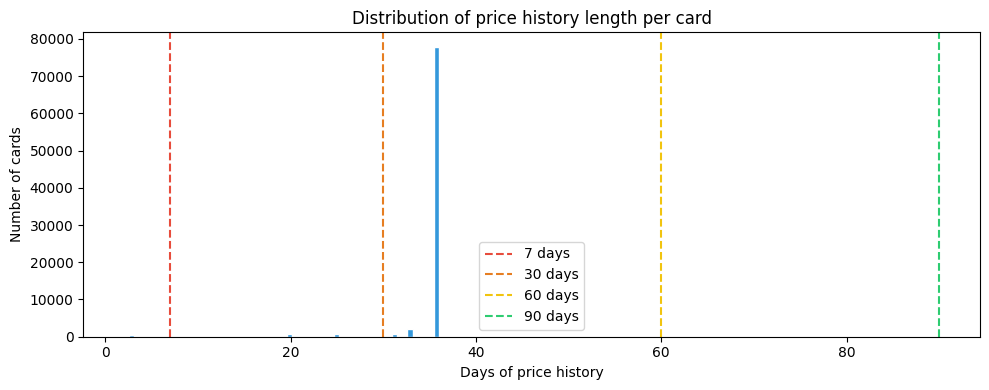

In [63]:
# Histogram of history length distribution.
# Vertical lines at 7, 30, 60, 90 days show modeling feasibility thresholds.
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(history_length["n_days"], bins=60, color="#3498db", edgecolor="white")

for days, color in [(7, "#e74c3c"), (30, "#e67e22"), (60, "#f1c40f"), (90, "#2ecc71")]:
    ax.axvline(days, color=color, linestyle="--", linewidth=1.5, label=f"{days} days")

ax.set_xlabel("Days of price history")
ax.set_ylabel("Number of cards")
ax.set_title("Distribution of price history length per card")
ax.legend()
plt.tight_layout()
plt.show()

In [64]:
# Confirm the actual date range in gold_price_features.
# This anchors all threshold calculations above to real calendar dates.
gold_connection.execute("""
    SELECT MIN(snapshot_date), MAX(snapshot_date), COUNT(DISTINCT snapshot_date)
    FROM gold_price_features
""").fetchone()

('2026-05-26', '2026-07-09', 36)

In [65]:
# Close all database connections to release file locks
bronze_connection.close()
silver_connection.close()
gold_connection.close()

OBSERVATIONS:
- Date range: 2026-05-26 → 2026-07-09 (36 distinct snapshot dates)
- Median history per card: 36 days
- % cards with <7 days of history:  0.6%  → 99.4% of cards qualify for t+7 targets
- % cards with <30 days of history: 2.6%  → 97.4% of cards now qualify for t+30 targets
- % cards with <90 days of history: 100.0% ⚠️ → t+90 targets still INFEASIBLE

CONCLUSION: The dataset has grown enough that medium-term targets are now viable.
With a median of 36 days of history, both the 7-day and 30-day rolling windows and the
t+7 and t+30 prediction targets are usable for the large majority of cards. Only the
90-day target remains infeasible — no card yet has 90 days of history (max observed = 36 days).

This is a fundamental constraint for t+90 only, not a data quality issue.

DECISION:
1. Current training scope: t+7 and t+30 prediction targets are both viable
   (99.4% and 97.4% of cards qualify, respectively).
2. t+90 targets: still infeasible: defer until dataset covers ≥90 days of real history
   (currently 36 days; at the observed ~0.8 snapshot/day average cadence this implies
   roughly 2-3 more months of collection).
3. Keep the pipeline check that aborts model training if max(snapshot_date) -
   min(snapshot_date) < required_horizon — this prevents silent training on an
   insufficient history window, and remains relevant for the t+90 case.

## Final Conclusions

### Data Structure

| | |
|---|---|
| All tables present? | YES |
| Tables with problems | NONE |
| Sizes (bronze) | 531,765 Scryfall cards / 110,544 MTGJson cards / 19,089,994 Scryfall price rows + 84,420,980 MTGJson price rows |
| Sizes (silver → gold) | 509,736 cards (silver_cards) → 93,400 cards (gold_card_features) / 3,498,614 price rows (silver_prices_history → gold_price_features) |
| Silver tables | 6 (incl. `silver_language_prices_history`) |
| Gold tables | 9 (incl. `gold_language_premiums`) |

> Silver: 531,765 Scryfall cards → 509,736 silver_cards rows (1 row per card face, not per printing).
> Gold: 509,736 → 93,400 — Gold excludes Scryfall-only cards (no uuid); only MTGJson-matched cards are modelled.
> Language variant tables cover 414,792 of 416,336 Scryfall-only rows (99.6% resolve to a canonical UUID).

All three tiers are fully populated and consistent. The row reduction from Bronze to Silver is expected — Silver de-duplicates by card face rather than by printing. The larger reduction from Silver to Gold is intentional: Gold is scoped to MTGJson-matched cards only, since Scryfall-only rows lack the uuid needed for price modelling.

---

### Data Quality

| | |
|---|---|
| Columns with unexpected NULL% | edhrec_rank rose to ~82% NULL at the silver_cards level (was ~6% at bronze) — see section 5 |
| Confirmed duplicates | 5 of 6 checked keys unique; `bronze_mtgjson_prices_history` is not unique on (uuid, snapshot_date) alone — structural (retailer × tx_type × finish grain), not a defect |
| silver_cards key checked | `scryfall_id` |
| canonical_uuid coverage | **99.6%** of Scryfall-only rows resolve to an English UUID (414,792 / 416,336) |
| Unresolved (0.4%) | digital exclusives / sets entirely absent from MTGJson |

**Two documented NULL regimes:**
- **~81.6%** (`uuid`, `tcgplayer_id`, `cardmarket_id`, `rulings`, `printings`, `original_types`/`original_supertypes`/`original_subtypes`) — MTGJson-linkage-only columns, absent for Scryfall-only cards. Note: `mana_value`, `set_code` and `is_reserved` are now fully populated (0% NULL) and are **no longer** part of this regime.
- **~48-100%** (`defense` 99.99%, `loyalty` 98.91%, `power`/`toughness` 51.09% each) — structural columns, not applicable to most card types.

Every column with a high NULL rate has a documented structural reason. The only column requiring active imputation strategy is `edhrec_rank`, where cards not listed on EDHREC (or lacking an MTGJson match) should receive a sentinel high-rank value to preserve monotonicity in tree-based models.

---

### Join & Coverage

| | |
|---|---|
| % cards with MTGJson data | **20.3%** (108,167 / 531,765) |
| EUR price coverage per card | **84.3%** of cards have ≥1 EUR price (82,876 / 98,353) |
| oracle_id conflicts | **0** cards (0 / 93,400 rows) |
| `has_mtgjson_data` flag | present in `gold_card_features` ✓ |

The MTGJson match rate of 20.3% is expected: MTGJson covers only paper English printings, while Scryfall includes all language variants, digital exclusives, and oversized promos. The `has_mtgjson_data` binary flag is the correct conditioning mechanism for downstream models. EUR price coverage of 84.3% is healthy; the remaining 15.7% are cards that have never had a Cardmarket listing (tokens, basic lands, digital-only cards).

---

### Silver / Forward-fill

| | |
|---|---|
| max_gap in date spine (sample) | **6 days** — real collection gaps found (e.g. 2026-06-23 → 2026-06-29) |
| run-length distribution (500 cards, 613 runs) | min=1, mean=29.4, median=36, p95=36, max=36 days |
| Staleness flag needed? | **YES** — 15,940 cards (16.2% of 98,353) have no real EUR price; entire history is forward-filled |

The daily cadence has real gaps (max_gap = 6 days), unlike the originally assumed uninterrupted cadence. Despite this, most sampled cards show a run length at or near the full 36-snapshot window, meaning their EUR price has not changed at all yet — this reflects price stability, not additional forward-fill staleness. The staleness flag (`days_since_last_real_price`) remains necessary: 16.2% of cards have never had a real EUR price and their entire price history is NULL-filled.

---

### Price History

| | |
|---|---|
| Date range | 2026-05-26 → 2026-07-09 |
| Distinct snapshot dates | **36** |
| Median history per card | **36 days** |
| % cards with <7 days | **0.6%** |
| % cards with <30 days | **2.6%** |
| % cards with <90 days | **100.0%** ⚠️ |

The large majority of cards now have enough history for both t+7 (99.4% qualify) and t+30 (97.4% qualify) prediction targets. Only the 90-day target remains infeasible — no card has yet accumulated 90 days of history (max observed = 36 days). This is a hard data constraint for t+90 only, not a pipeline deficiency.

---

### Decisions

| Decision | Value |
|---|---|
| Exclude split cards from training | **NO** — oracle_id clean, no conflicts (0 / 93,400) |
| Minimum history threshold | **7 days** (99.4% of cards qualify) |
| Max rolling window | **30 days** (97.4% of cards have ≥30 days of history; 90-day window still infeasible) |
| Max prediction target | **t+30** (t+90 infeasible — max history is 36 days) |
| edhrec_rank imputation | sentinel = MAX + 1 (preserve monotonicity for unranked cards); NULL rate is now ~82% at the silver_cards level |
| MTGJson-only columns | condition on `has_mtgjson_data`; note `mana_value`/`set_code`/`is_reserved` are now fully populated and no longer need this treatment — only pure-linkage columns (`uuid`, `tcgplayer_id`, `cardmarket_id`, etc.) do |
| lang_eur_premium feature | **EXCLUDED** — still only 11 of 414,795 tracked variants show a non-1.0 premium; revisit when a Cardmarket per-language scraper is added |